# 学习曲线


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import joblib
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("数据加载完成")
print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 加载最终调优的模型（Day 18 或 Day 19）
try:
    final_xgb = joblib.load('../models/day18_xgb_final.pkl')
    print("\n✓ 加载了 Day 18 最终模型")
except:
    try:
        final_xgb = joblib.load('../models/day17_xgb_tuned_learning.pkl')
        print("\n✓ 加载了 Day 17 模型")
    except:
        print("\n⚠️  未找到已保存的模型，将创建一个默认模型")
        final_xgb = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        final_xgb.fit(X_train, y_train)

# 查看模型参数
params = final_xgb.get_params()
print(f"\n当前模型参数:")
print(f"  n_estimators: {params['n_estimators']}")
print(f"  max_depth: {params['max_depth']}")
print(f"  learning_rate: {params['learning_rate']}")
print(f"  subsample: {params['subsample']}")
print(f"  colsample_bytree: {params['colsample_bytree']}")

# 基准性能
test_r2 = final_xgb.score(X_test, y_test)
train_r2 = final_xgb.score(X_train, y_train)
print(f"\n基准性能:")
print(f"  训练集 R²: {train_r2:.4f}")
print(f"  测试集 R²: {test_r2:.4f}")
print(f"  差距: {train_r2 - test_r2:.4f}")

数据加载完成
训练集: 3811 样本
测试集: 953 样本

✓ 加载了 Day 18 最终模型

当前模型参数:
  n_estimators: 500
  max_depth: 8
  learning_rate: 0.01
  subsample: 0.5
  colsample_bytree: 0.5

基准性能:
  训练集 R²: 0.9207
  测试集 R²: 0.6896
  差距: 0.2311


In [7]:
# 计算学习曲线
print("\n" + "="*70)
print("计算学习曲线")
print("="*70)

# 定义训练集大小的取样点
# 从 10% 到 100%，分 10 个点
train_sizes = np.linspace(0.1, 1.0, 10)

print(f"\n训练集大小采样点:")
print(f"  比例: {train_sizes}")
print(f"  实际样本数: {(train_sizes * len(X_train)).astype(int)}")

# 计算学习曲线
print(f"\n开始计算学习曲线（可能需要 2-3 分钟）...")
print(f"  5 折交叉验证 × 10 个训练集大小 = 50 次训练")

import time
start_time = time.time()

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=final_xgb,
    X=X_train,
    y=y_train,
    cv=5,                      # 5 折交叉验证
    train_sizes=train_sizes,   # 训练集大小
    scoring='r2',              # 评估指标
    n_jobs=-1,                 # 并行计算
    verbose=0,
    shuffle=True,
    random_state=42
)

calc_time = time.time() - start_time
print(f"\n✓ 计算完成，耗时 {calc_time:.2f} 秒")

# train_scores 和 val_scores 的形状：(n_train_sizes, n_cv_folds)
# 例如：(10, 5) → 10 个训练集大小，每个做 5 折 CV

print(f"\n结果矩阵形状:")
print(f"  train_scores: {train_scores.shape}")
print(f"  val_scores: {val_scores.shape}")

# 计算每个训练集大小的平均分数和标准差
train_mean = train_scores.mean(axis=1)  # 对 5 折求平均
train_std = train_scores.std(axis=1)    # 对 5 折求标准差

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# 创建结果 DataFrame
learning_curve_df = pd.DataFrame({
    'train_size': train_sizes_abs,
    'train_size_pct': train_sizes * 100,
    'train_mean': train_mean,
    'train_std': train_std,
    'val_mean': val_mean,
    'val_std': val_std,
    'gap': train_mean - val_mean
})

print("\n学习曲线数据:")
print(learning_curve_df.to_string(index=False))


计算学习曲线

训练集大小采样点:
  比例: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
  实际样本数: [ 381  762 1143 1524 1905 2286 2667 3048 3429 3811]

开始计算学习曲线（可能需要 2-3 分钟）...
  5 折交叉验证 × 10 个训练集大小 = 50 次训练

✓ 计算完成，耗时 58.89 秒

结果矩阵形状:
  train_scores: (10, 5)
  val_scores: (10, 5)

学习曲线数据:
 train_size  train_size_pct  train_mean  train_std  val_mean  val_std      gap
        304            10.0    0.971904   0.009337  0.508289 0.079466 0.463616
        609            20.0    0.955947   0.010148  0.527974 0.063605 0.427973
        914            30.0    0.953050   0.004939  0.535923 0.082356 0.417128
       1219            40.0    0.952002   0.004338  0.547626 0.070026 0.404376
       1524            50.0    0.951161   0.003848  0.561915 0.070731 0.389246
       1828            60.0    0.946667   0.003336  0.578332 0.069974 0.368335
       2133            70.0    0.940153   0.004923  0.578208 0.071053 0.361945
       2438            80.0    0.935775   0.003634  0.577595 0.068505 0.358180
       2743          


可视化学习曲线


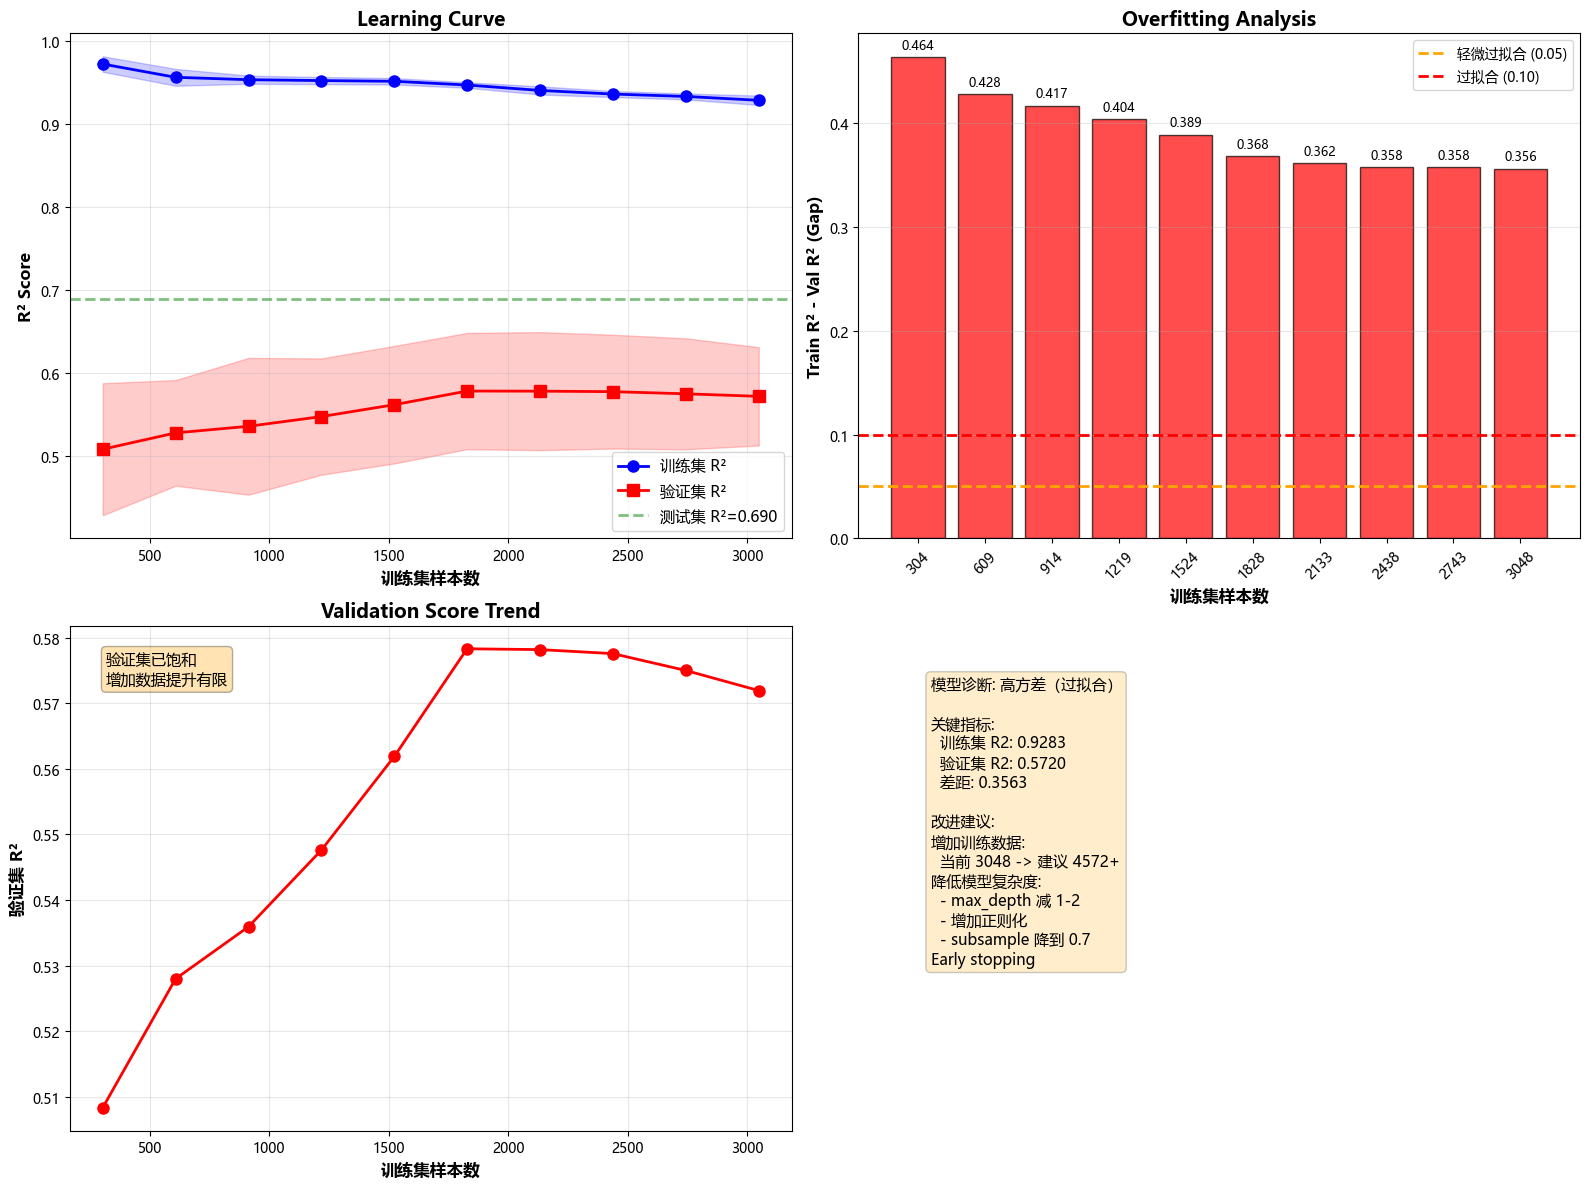


✓ 学习曲线分析图已保存

诊断结果

高方差（过拟合）

改进建议:
  增加训练数据:
    当前 3048 -> 建议 4572+
  降低模型复杂度:
    - max_depth 减 1-2
    - 增加正则化
    - subsample 降到 0.7
  Early stopping


In [8]:
# 可视化
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("\n" + "="*70)
print("可视化学习曲线")
print("="*70)

# 创建多个子图
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ========== 子图 1：标准学习曲线 ==========
ax1 = axes[0, 0]

# 训练集曲线（蓝色，带阴影）
ax1.plot(train_sizes_abs, train_mean, 'o-', color='blue', 
         linewidth=2, markersize=8, label='训练集 R²')
ax1.fill_between(train_sizes_abs, 
                  train_mean - train_std, 
                  train_mean + train_std,
                  alpha=0.2, color='blue')

# 验证集曲线（红色，带阴影）
ax1.plot(train_sizes_abs, val_mean, 's-', color='red', 
         linewidth=2, markersize=8, label='验证集 R²')
ax1.fill_between(train_sizes_abs, 
                  val_mean - val_std, 
                  val_mean + val_std,
                  alpha=0.2, color='red')

ax1.set_xlabel('训练集样本数', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Learning Curve', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, alpha=0.3)

# 添加参考线（最终测试集性能）
ax1.axhline(test_r2, color='green', linestyle='--', linewidth=2, 
            alpha=0.5, label=f'测试集 R²={test_r2:.3f}')
ax1.legend(loc='lower right', fontsize=11)

# ========== 子图 2：过拟合程度分析 ==========
ax2 = axes[0, 1]

gaps = train_mean - val_mean
colors = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' for g in gaps]

bars = ax2.bar(range(len(train_sizes_abs)), gaps, color=colors, 
               alpha=0.7, edgecolor='black')
ax2.axhline(0.05, color='orange', linestyle='--', linewidth=2, 
            label='轻微过拟合 (0.05)')
ax2.axhline(0.10, color='red', linestyle='--', linewidth=2, 
            label='过拟合 (0.10)')

ax2.set_xticks(range(len(train_sizes_abs)))
ax2.set_xticklabels([f'{int(s)}' for s in train_sizes_abs], rotation=45)
ax2.set_xlabel('训练集样本数', fontsize=12, fontweight='bold')
ax2.set_ylabel('Train R² - Val R² (Gap)', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, gaps)):
    ax2.text(bar.get_x() + bar.get_width()/2., val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# ========== 子图 3：验证集分数变化趋势 ==========
ax3 = axes[1, 0]

# 计算验证集分数的增量
val_increments = [0] + [val_mean[i] - val_mean[i-1] for i in range(1, len(val_mean))]

ax3.plot(train_sizes_abs, val_mean, 'o-', linewidth=2, 
         color='red', markersize=8, label='验证集 R²')
ax3.set_xlabel('训练集样本数', fontsize=12, fontweight='bold')
ax3.set_ylabel('验证集 R²', fontsize=12, fontweight='bold')
ax3.set_title('Validation Score Trend', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 标注趋势
if val_increments[-1] > 0.01:
    trend_text = "验证集仍在上升\n增加数据有帮助"
    trend_color = 'green'
elif abs(val_increments[-1]) < 0.01:
    trend_text = "验证集已饱和\n增加数据提升有限"
    trend_color = 'orange'
else:
    trend_text = "验证集下降\n可能过拟合"
    trend_color = 'red'

ax3.text(0.05, 0.95, trend_text, transform=ax3.transAxes, 
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor=trend_color, alpha=0.3))

# ========== 子图 4：诊断建议 ==========
ax4 = axes[1, 1]
ax4.axis('off')

# 根据学习曲线诊断模型状态
final_train_r2 = train_mean[-1]
final_val_r2 = val_mean[-1]
final_gap = final_train_r2 - final_val_r2

# 诊断逻辑
if final_val_r2 < 0.7 and final_gap < 0.05:
    diagnosis = "高偏差（欠拟合）"
    diagnosis_color = 'red'
    suggestions = [
        "增加模型复杂度:",
        "  - max_depth 加大 2-3",
        "  - n_estimators 加 100",
        "  - 减少正则化",
        "特征工程:",
        "  - 添加交互特征",
        "  - 多项式特征",
        "不要加数据（没用）"
    ]
elif final_gap > 0.15:
    diagnosis = "高方差（过拟合）"
    diagnosis_color = 'orange'
    suggestions = [
        "增加训练数据:",
        f"  当前 {int(train_sizes_abs[-1])} -> 建议 {int(train_sizes_abs[-1]*1.5)}+",
        "降低模型复杂度:",
        "  - max_depth 减 1-2",
        "  - 增加正则化",
        "  - subsample 降到 0.7",
        "Early stopping"
    ]
else:
    diagnosis = "理想状态（Good Fit）"
    diagnosis_color = 'green'
    suggestions = [
        "当前模型已优化",
        "  泛化能力良好",
        "  无明显过拟合",
        "可选微调:",
        "  - 特征选择",
        "  - 模型融合",
        f"当前性能: R2={final_val_r2:.3f}"
    ]

# 绘制诊断结果
diagnosis_text = f"模型诊断: {diagnosis}\n\n"
diagnosis_text += "关键指标:\n"
diagnosis_text += f"  训练集 R2: {final_train_r2:.4f}\n"
diagnosis_text += f"  验证集 R2: {final_val_r2:.4f}\n"
diagnosis_text += f"  差距: {final_gap:.4f}\n\n"
diagnosis_text += "改进建议:\n"
diagnosis_text += "\n".join(suggestions)

ax4.text(0.1, 0.9, diagnosis_text, 
         transform=ax4.transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor=diagnosis_color, alpha=0.2))

plt.tight_layout()
plt.savefig('../figures/day20_learning_curve_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ 学习曲线分析图已保存")

# 打印诊断结果
print("\n" + "="*70)
print("诊断结果")
print("="*70)
print(f"\n{diagnosis}\n")
print("改进建议:")
for suggestion in suggestions:
    print(f"  {suggestion}")


对比实验：简单模型 vs 复杂模型

计算 欠拟合模型 的学习曲线...

计算 理想模型 的学习曲线...

计算 过拟合模型 的学习曲线...


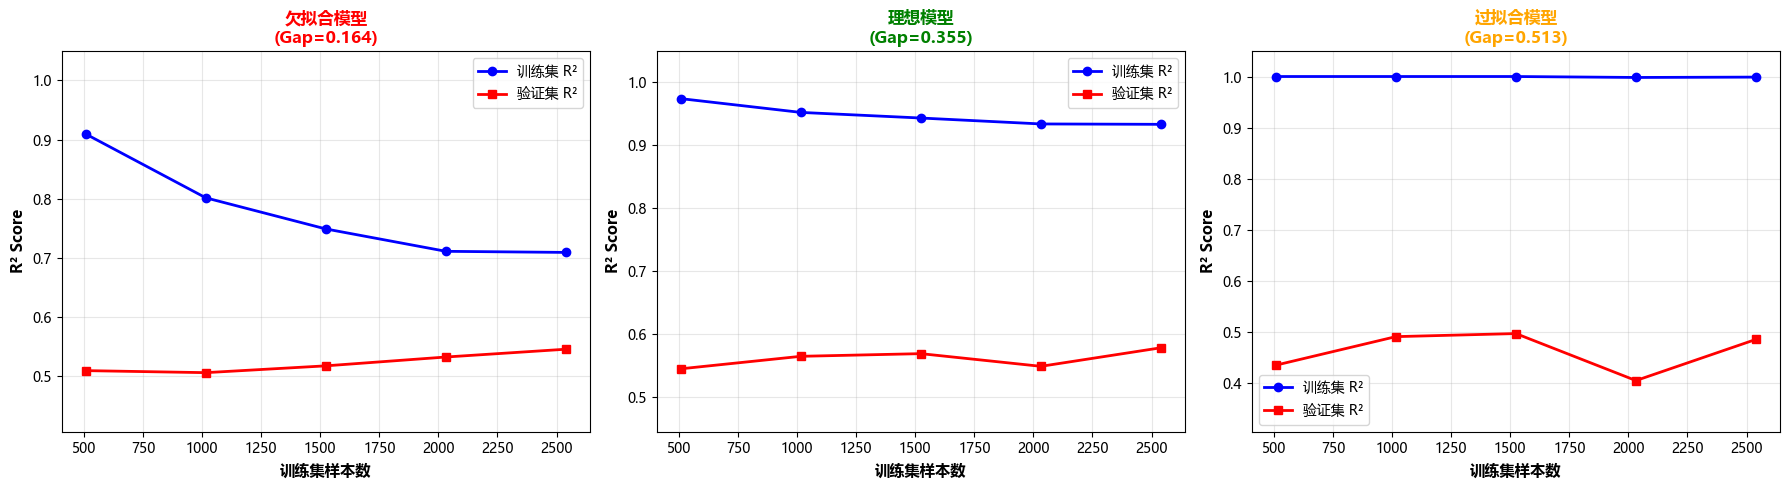


✓ 学习曲线对比图已保存


In [10]:
# 对比不同模型的曲线
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("\n" + "="*70)
print("对比实验：简单模型 vs 复杂模型")
print("="*70)

# 创建三个不同复杂度的模型
models = {
    '欠拟合模型': xgb.XGBRegressor(
        n_estimators=50,
        max_depth=2,  # 很浅
        learning_rate=0.3,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ),
    '理想模型': final_xgb,
    '过拟合模型': xgb.XGBRegressor(
        n_estimators=500,
        max_depth=15,  # 很深
        learning_rate=0.1,
        subsample=1.0,  # 不采样
        colsample_bytree=1.0,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )
}

# 计算每个模型的学习曲线
comparison_results = {}

for model_name, model in models.items():
    print(f"\n计算 {model_name} 的学习曲线...")
    
    train_sizes_abs_m, train_scores_m, val_scores_m = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=3,  # 减少折数以加快速度
        train_sizes=np.linspace(0.2, 1.0, 5),  # 减少采样点
        scoring='r2',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    
    comparison_results[model_name] = {
        'train_sizes': train_sizes_abs_m,
        'train_mean': train_scores_m.mean(axis=1),
        'val_mean': val_scores_m.mean(axis=1)
    }

# 可视化对比
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, results) in enumerate(comparison_results.items()):
    ax = axes[idx]
    
    ax.plot(results['train_sizes'], results['train_mean'], 
            'o-', linewidth=2, label='训练集 R²', color='blue')
    ax.plot(results['train_sizes'], results['val_mean'], 
            's-', linewidth=2, label='验证集 R²', color='red')
    
    # 计算最终差距
    final_gap_m = results['train_mean'][-1] - results['val_mean'][-1]
    
    # 设置标题颜色
    if '欠拟合' in model_name:
        title_color = 'red'
    elif '过拟合' in model_name:
        title_color = 'orange'
    else:
        title_color = 'green'
    
    ax.set_xlabel('训练集样本数', fontsize=11, fontweight='bold')
    ax.set_ylabel('R² Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}\n(Gap={final_gap_m:.3f})', 
                 fontsize=12, fontweight='bold', color=title_color)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    # 每个子图用自己的范围，不过拟合模型的验证集可能很低
    val_min = results['val_mean'].min()
    ax.set_ylim([max(0, val_min - 0.1), 1.05])

plt.tight_layout()
plt.savefig('../figures/day20_learning_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ 学习曲线对比图已保存")

可以得出增加数据能改善R2 但是边际递减 